In [1]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import copy
import itertools

In [2]:
file_path = "dataset_ovarian_cancer.txt"

df = pd.read_csv(
    file_path,
    sep="\t",
    skiprows=5
)

# Remove benign and borderline samples
df = df[~df["Diagnosis"].isin(["benign", "borderline"])].copy()

print(df.head())
print()
print("Shape:", df.shape)
print()
print("Columns:")
print(df.columns)

  Sample-ID  Replicate      PROK1        WFDC2        KRT19     FR-alpha  \
0      id_1          1   51.27954   2684.67462  814977.3242    978.62687   
1      id_1          2   61.33529   2837.46526  896027.9581   1105.94503   
6      id_4          1   64.48318  17540.11449  20619803.29   3470.07213   
7      id_4          2   69.73640  16819.42076  18572286.48   3369.12071   
8      id_5          1  102.80136  47140.90177  1965477.203  33382.84010   

        ICOSLG         CDH3        MSMB    CLEC6A     TACSTD2       MUC-16  \
0   4962.66112  38555.25779  4923.13477  15.18093   160.80636  16652.85209   
1   5416.43019  39359.37085  4895.63176  14.14949   161.81711  17377.84122   
6   4673.40098  46314.54069  6192.18559  13.72160   401.55326       > ULOQ   
7   4424.60677  49723.35415  5950.36607  13.59799   419.70932       > ULOQ   
8  11875.94962  70572.30654  4343.25094  28.61630  1803.12287       > ULOQ   

        SPINT1  AgeAtDiag Diagnosis  
0   9610.23806         49         I 

In [3]:
features = [
    "PROK1",
    "WFDC2",
    "KRT19",
    "FR-alpha",
    "ICOSLG",
    "CDH3",
    "MSMB",
    "CLEC6A",
    "TACSTD2",
    "MUC-16",
    "SPINT1",
    "AgeAtDiag"
]

target = "Diagnosis"

uloq = {
    "PROK1": 16883.06305,
    "WFDC2": 181210.6285,
    "KRT19": 68900244.48,
    "FR-alpha": 163421.4035,
    "ICOSLG": 55648.31473,
    "CDH3": 638185.7656,
    "MSMB": 177291.4083,
    "CLEC6A": 13291.04962,
    "TACSTD2": 33922.31855,
    "MUC-16": 2288168.669,
    "SPINT1": 193069.9522
}

for feature in uloq:
    df[feature] = df[feature].replace(
        "> ULOQ",
        uloq[feature]
    )

    df[feature] = pd.to_numeric(
        df[feature],
        errors="coerce"
    )

print("Missing values:")
print(df[features].isna().sum())

Missing values:
PROK1        4
WFDC2        4
KRT19        4
FR-alpha     4
ICOSLG       4
CDH3         4
MSMB         4
CLEC6A       4
TACSTD2      4
MUC-16       4
SPINT1       4
AgeAtDiag    0
dtype: int64


In [4]:
df_patient = (
    df.groupby("Sample-ID")
      .agg({
          **{feature: "mean" for feature in features},
          "Diagnosis": "first"
      })
      .reset_index()
)

print("Patient-level dataset:")
print(df_patient.head())

print()
print("Shape:", df_patient.shape)

Patient-level dataset:
  Sample-ID      PROK1        WFDC2         KRT19     FR-alpha       ICOSLG  \
0      id_1  56.307415  2761.069940  8.555026e+05  1042.285950  5189.545655   
1     id_10  60.051290  2692.821970  7.599913e+05   911.213855  5974.368245   
2    id_105  59.653160  3827.338373  5.231513e+06  1045.533663  4581.916750   
3    id_106  64.261070  6142.683357  1.277974e+06  1965.823370  5385.793827   
4    id_111  80.136683  9746.318057  2.676830e+06  2918.588623  5287.917977   

           CDH3         MSMB     CLEC6A     TACSTD2         MUC-16  \
0  38957.314320  4909.383265  14.665210  161.311735   17015.346655   
1  28535.242535  1702.930035   9.942800  192.346485    3963.833860   
2  40000.848533  5791.367120  12.804823  453.801403  773309.319100   
3  43192.315020  6375.488787  11.624357  216.743243  696577.633900   
4  57110.993503  7675.507700  11.965677  144.621597  161804.189800   

         SPINT1  AgeAtDiag Diagnosis  
0   9234.424980       49.0         I  
1  

In [5]:
X = df_patient[features].copy()
y = df_patient[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

X shape: (90, 12)
y shape: (90,)
Classes:
['I' 'II' 'III' 'IV']


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (63, 12)
Validation: (13, 12)
Test: (14, 12)


In [7]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)

X_val = imputer.transform(X_val)

X_test = imputer.transform(X_test)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [8]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [9]:
batch_size = 16

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [10]:
print("Train:", X_train_tensor.shape)
print("Validation:", X_val_tensor.shape)
print("Test:", X_test_tensor.shape)

print()

print("Example X:")
print(X_train_tensor[0])

print()

print("Example y:")
print(y_train_tensor[0])

print()

print("Classes:")
print(label_encoder.classes_)

counts = np.bincount(y_encoded)
for cls, n in zip(label_encoder.classes_, counts):
    print(cls, n)

Train: torch.Size([63, 12])
Validation: torch.Size([13, 12])
Test: torch.Size([14, 12])

Example X:
tensor([-0.6848, -0.7972, -0.6668, -0.4354,  0.3338, -0.4306,  1.2219, -1.1478,
        -0.5244, -1.0426, -0.5526,  1.7391])

Example y:
tensor(3)

Classes:
['I' 'II' 'III' 'IV']
I 14
II 11
III 40
IV 25


In [11]:
#MLP

class MLP(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.25),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [12]:
# MODEL

input_size = len(features)
num_classes = len(label_encoder.classes_)

model = MLP(
    input_size=input_size,
    num_classes=num_classes
)

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=16, out_features=4, bias=True)
  )
)


In [13]:
# DEVICE 
 
device = torch.device( 
    "cuda" if torch.cuda.is_available() else "cpu" 
) 
 
print("Device:", device) 
 
model = model.to(device)

Device: cpu


In [14]:
# LOSS & OPT

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.00026,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8
)

Epoch [1/500] Train Loss: 1.3350 Train Acc: 0.365 Val Loss: 1.339574 Val Acc: 0.231LR: 0.00026000
Epoch [2/500] Train Loss: 1.3372 Train Acc: 0.365 Val Loss: 1.334358 Val Acc: 0.385LR: 0.00026000
Epoch [3/500] Train Loss: 1.3632 Train Acc: 0.302 Val Loss: 1.326368 Val Acc: 0.385LR: 0.00026000
Epoch [4/500] Train Loss: 1.3529 Train Acc: 0.349 Val Loss: 1.318125 Val Acc: 0.385LR: 0.00026000
Epoch [5/500] Train Loss: 1.3559 Train Acc: 0.349 Val Loss: 1.309618 Val Acc: 0.385LR: 0.00026000
Epoch [6/500] Train Loss: 1.3508 Train Acc: 0.333 Val Loss: 1.302204 Val Acc: 0.308LR: 0.00026000
Epoch [7/500] Train Loss: 1.3840 Train Acc: 0.238 Val Loss: 1.296253 Val Acc: 0.308LR: 0.00026000
Epoch [8/500] Train Loss: 1.3485 Train Acc: 0.317 Val Loss: 1.292004 Val Acc: 0.308LR: 0.00026000
Epoch [9/500] Train Loss: 1.3135 Train Acc: 0.317 Val Loss: 1.287183 Val Acc: 0.308LR: 0.00026000
Epoch [10/500] Train Loss: 1.3095 Train Acc: 0.381 Val Loss: 1.282650 Val Acc: 0.308LR: 0.00026000
Epoch [11/500] Trai

C:\Users\syrjy\AppData\Local\Temp\ipykernel_724\1671023071.py:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


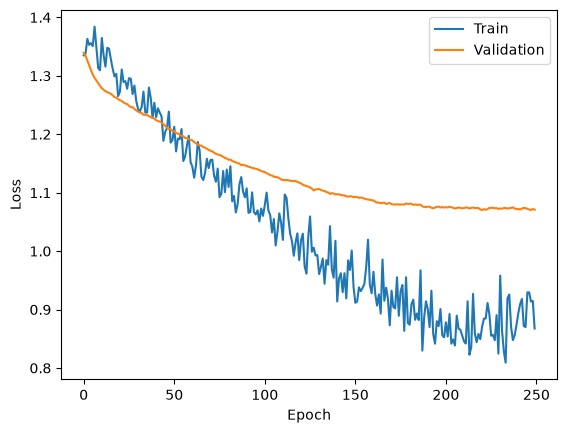

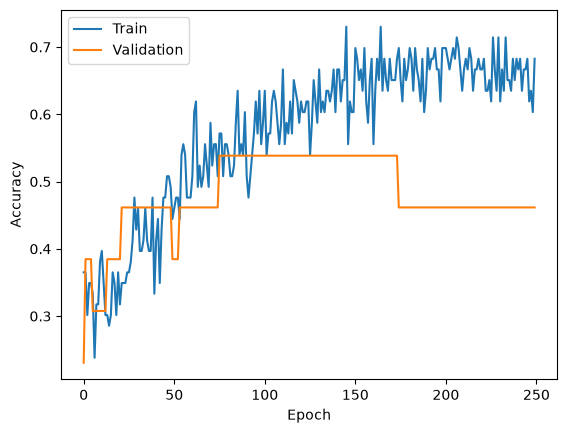

In [15]:
# TRAINING

num_epochs = 500

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
epochs_without_improvement = 0


for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # Statistics
        running_loss += loss.item() * X_batch.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss = running_loss / total
    val_accuracy = correct / total

    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
    
        best_val_loss = val_loss
        epochs_without_improvement = 0
    
        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        best_epoch = epoch

    else:
    
        epochs_without_improvement += 1
    
    
    if epochs_without_improvement >= 30:
    
        print("Early stopping!")
    
        break

    # Save statistics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.3f} "
        f"Val Loss: {val_loss:.6f} "
        f"Val Acc: {val_accuracy:.3f}"
        f"LR: {optimizer.param_groups[0]['lr']:.8f}"
    )

plt.figure()

model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

print()
print("Best model was from epoch:", best_epoch + 1)
print("Best validation loss:", best_val_loss)


plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

plt.figure()

plt.plot(train_accuracies, label="Train")
plt.plot(val_accuracies, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [16]:
# EVALUATION

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_targets.extend(
            y_batch.numpy()
        )

test_accuracy = accuracy_score(
    all_targets,
    all_predictions
)

print(f"Test accuracy: {test_accuracy:.3f}")

Test accuracy: 0.286


              precision    recall  f1-score   support

           I       0.00      0.00      0.00         2
          II       0.00      0.00      0.00         2
         III       0.29      0.33      0.31         6
          IV       0.29      0.50      0.36         4

    accuracy                           0.29        14
   macro avg       0.14      0.21      0.17        14
weighted avg       0.20      0.29      0.24        14

[[0 0 2 0]
 [0 0 1 1]
 [0 0 2 4]
 [0 0 2 2]]


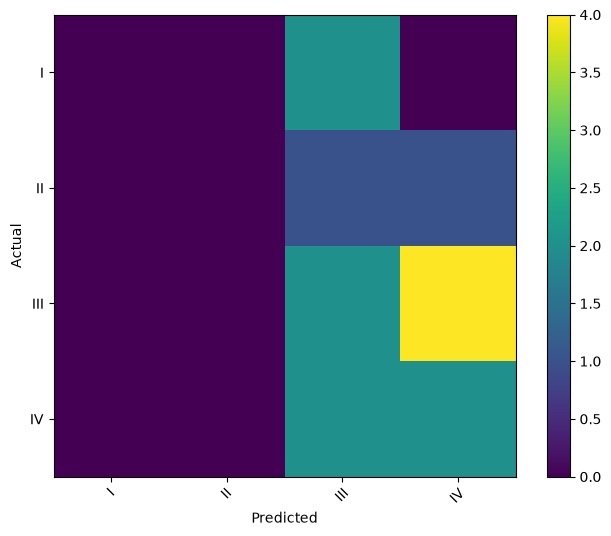

In [17]:
# CLASSIFICATION REPORT

print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

cm = confusion_matrix(
    all_targets,
    all_predictions
)

print(cm)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(num_classes),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(num_classes),
    label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()